## Model Evaluation

In [18]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from wandb_example import eval

cwd = Path.cwd().resolve()
if cwd.name == "notebooks":
    os.chdir(cwd.parent)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load results

In [8]:
project_dir = Path.cwd()
checkpoints_dir = project_dir.joinpath('checkpoints', 'default')
targets, preds, probs, embeddings, stats, wandb_id = eval.load_eval(checkpoints_dir, 'default')
print('Logged in W&B with id = ', wandb_id)

Logged in W&B with id =  y4gr6s1m


### Learning curves

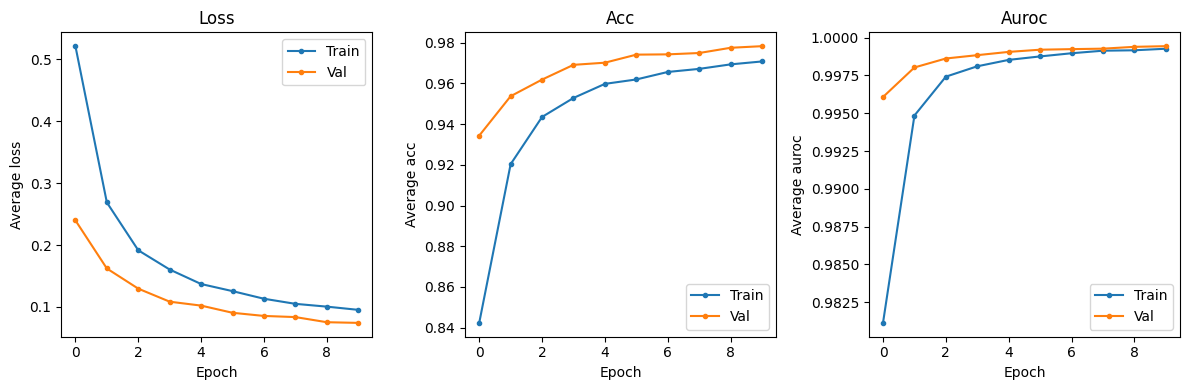

In [32]:
metrics = ['loss', 'acc', 'auroc']
fig, ax = plt.subplots(1, len(metrics), figsize=(12, 4))

for i in range(len(metrics)):
    ax[i].plot(stats[f'{metrics[i]}_train'], '-o', markersize=3)
    ax[i].plot(stats[f'{metrics[i]}_val'], '-o', markersize=3)
    ax[i].legend(['Train', 'Val'])
    ax[i].set_title(metrics[i].capitalize())
    ax[i].set_xlabel('Epoch')
    ax[i].set_ylabel(f'Average {metrics[i]}')

plt.tight_layout()

### Classification metrics

In [16]:
auroc, auprc, acc, kappa = eval.get_all_metrics(targets, preds, probs)
print(f'AUROC = {auroc:.4f}')
print(f'AUPRC = {auprc:.4f}')
print(f'Balanced accuracy = {acc:.4f}')
print(f'Quadratic Weighted Kappa = {kappa:.4f}')

AUROC = 0.9997
AUPRC = 0.9980
Balanced accuracy = 0.9808
Quadratic Weighted Kappa = 0.9787


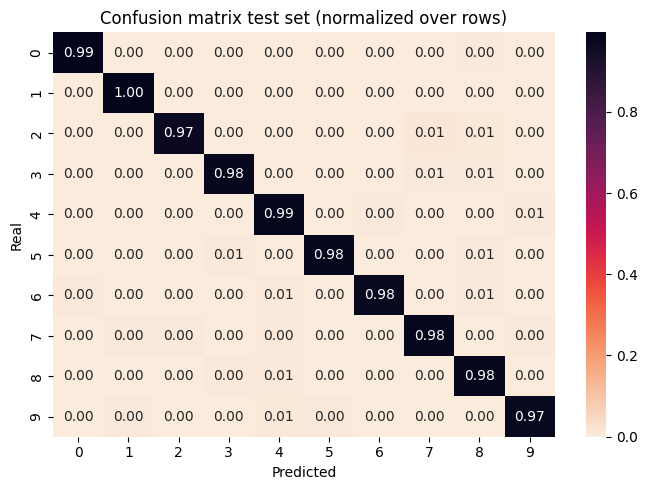

In [23]:
# Confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
cf_matrix = confusion_matrix(targets, preds, normalize='true')
sns.heatmap(cf_matrix, annot=True, fmt='.2f', cmap='rocket_r', ax=ax,)

ax.set_ylabel('Real')
ax.set_xlabel('Predicted')
ax.set_title('Confusion matrix test set (normalized over rows)')
plt.tight_layout()